[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/mast/2026-07-30-kepler-lightcurve-kepler10b/notebook.ipynb)

# Seeing Kepler-10b's transit dips in a real Kepler light curve

Kepler-10b was one of Kepler's first confirmed rocky exoplanets -- a small, blisteringly hot world orbiting its star in less than a day. A transit light curve just tracks a star's brightness over time, and when a planet crosses in front of the star, brightness dips very slightly and briefly. I downloaded a real Kepler light curve for this star using `lightkurve` and looked for those dips directly.

In [1]:
import lightkurve as lk

search = lk.search_lightcurve('Kepler-10', mission='Kepler', cadence='long', quarter=3)
print(search)
lc = search.download()
print(lc)

SearchResult containing 2 data products.

 #       mission      year   author   exptime         target_name          distance
                                         s                                  arcsec 
--- ----------------- ---- ---------- ------- ---------------------------- --------
  0   Kepler Quarter  2009 KBONUS-BKG    1765 Gaia DR3 2132155017099178624      0.0
  1 Kepler Quarter 03 2009     Kepler    1800                kplr011904151      0.0
       time               flux        ... sap_quality flatten_mask
                      electron / s    ...                         
------------------ ------------------ ... ----------- ------------
120.53915626835078  383377.5911795517 ...           0            0
120.55959051754326  383529.5819407244 ...           0            0
120.58002466661856  383553.9935261434 ...           0            0
120.60045901546255  383799.9754925247 ...           0            0
120.62089326465502  383840.9853095833 ...           0            0
12

C:\Users\biswa\anaconda3\lib\site-packages\lightkurve\search.py:407: LightkurveWarning: Warning: 2 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


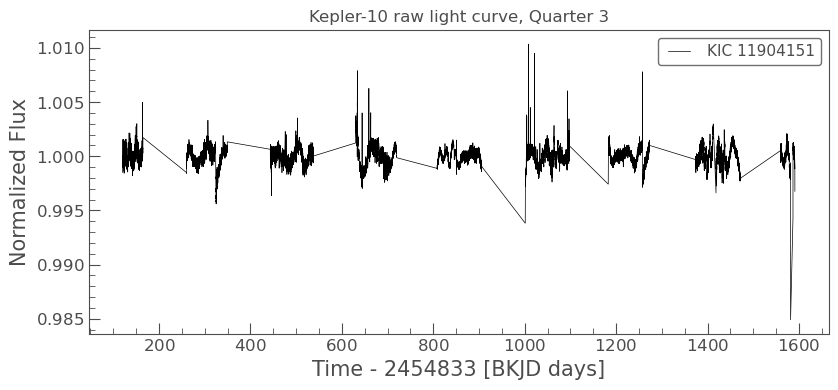

In [2]:
import matplotlib.pyplot as plt

lc_clean = lc.remove_nans().normalize()
ax = lc_clean.plot(color='black', lw=0.5)
ax.set_title('Kepler-10 raw light curve, Quarter 3')
plt.tight_layout()
plt.savefig('kepler10_full_lc.png', dpi=120)
plt.show()

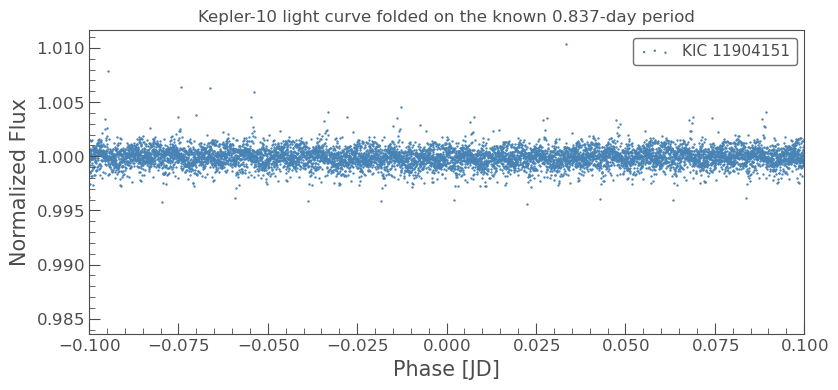

In [3]:
period = 0.837491  # days, published orbital period of Kepler-10b
t0 = 2454964.57513 - 2454833.0  # published transit epoch, converted to Kepler-time (BJD - 2454833)

folded = lc_clean.fold(period=period, epoch_time=t0)
ax = folded.scatter(s=2, color='steelblue')
ax.set_xlim(-0.1, 0.1)
ax.set_title('Kepler-10 light curve folded on the known 0.837-day period')
plt.tight_layout()
plt.savefig('kepler10_folded.png', dpi=120)
plt.show()

Folding the light curve on the known orbital period stacks every one of Kepler-10b's roughly 36 transits from this quarter on top of each other, which is what turns an otherwise invisible dip (way smaller than the noise in any single transit) into a small but clear dent right at phase zero. This stacking trick is exactly how such a tiny, rocky planet's transit was detected in the first place.

**What I'd look at next:** Fit an actual transit model (like the ones in the `batman` or `exoplanet` packages) to the folded curve to measure the transit depth and duration directly from this data, rather than relying on the published values.

**Citation:** This work made use of Kepler light curve data obtained from the Mikulski Archive for Space Telescopes (MAST) via the `lightkurve` package. See https://archive.stsci.edu/publishing/mission-acknowledgements for citation guidance.